# Test of the GlobalGraph class

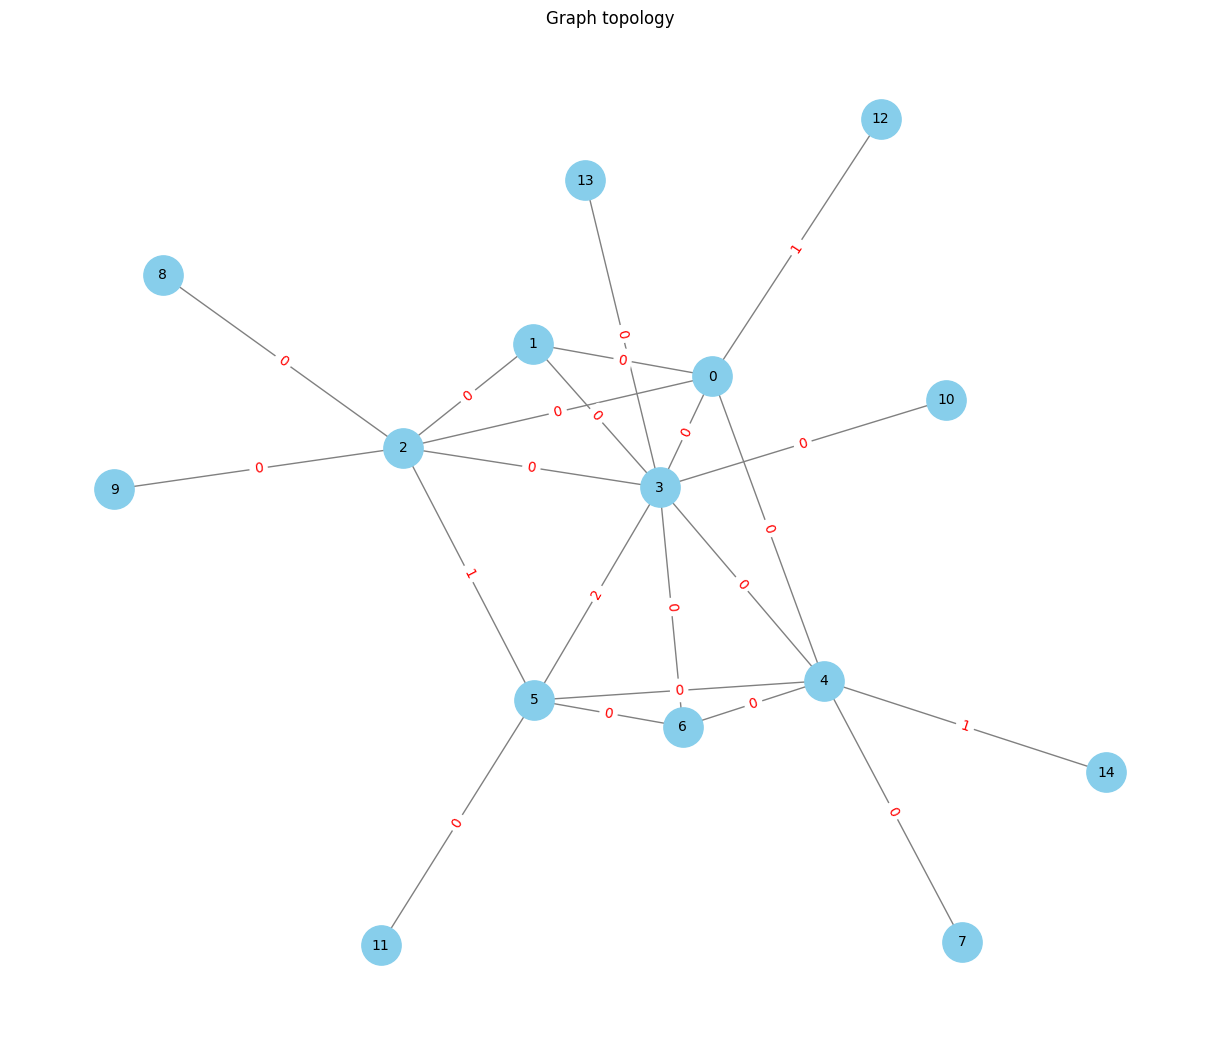

In [1]:
import networkx as nx
import json
from project.path_algorithms import centflow_shortest_path
import matplotlib.pyplot as plt


class GlobalGraph:

    def __init__(self, filename = "project/file/graph_networkx_15_nodes.json"):
        with open(filename, "r") as f:
            data = json.load(f)

        # Creating the graph in NetworkX
        self.graph = nx.Graph()

        # Adding nodes with IDs and attributes
        for node in data["nodes"]:
            node_id = node["id"]        
            attrs = {k: v for k, v in node.items() if k != "id"} 
            self.graph.add_node(node_id, **attrs)

        # Adding attribute with value 'usage' set to 0
        # Adding attribute with value 'capacity' set to 1000000
        # Or 'capacity' attribute could be set using qber.py and taking the BER
        for edge in data["links"]:
            src = edge["source"]
            dst = edge["target"]
            attrs = {k: v for k, v in edge.items() if k not in ["source", "target"]}

            attrs.setdefault("usage", 0)
            attrs.setdefault("capacity", 1000000)

            self.graph.add_edge(src, dst, **attrs)


    def increase_usage(self, tr_name: str):
        _, u, _, v = tr_name.split("_")
        u = int(u.replace("node", ""))
        v = int(v.replace("node", ""))

        if self.graph[u][v]['usage'] < 20:
            self.graph[u][v]['usage'] += 1


    def decrease_usage(self, tr_name: str):
        _, u, _, v = tr_name.split("_")
        u = int(u.replace("node", ""))
        v = int(v.replace("node", ""))

        if self.graph[u][v]['usage'] > 0:
            self.graph[u][v]['usage'] -= 1


    def best_available_path(self, src, dest):
        return centflow_shortest_path(self.graph, src, dest)


    def save_graph(self, tl, seed = 42):
        plt.figure(figsize=(12,10))
        pos = nx.spring_layout(self.graph, seed)
        nx.draw(
            self.graph, pos,
            with_labels=True,
            node_size=800,
            node_color="skyblue",
            edge_color="gray",
            font_size=10
        )
        edge_labels = nx.get_edge_attributes(self.graph, "usage")
        nx.draw_networkx_edge_labels(
            self.graph, pos,
            edge_labels=edge_labels,
            font_color="red"
        )
        plt.title(f"Graph topology at time {tl.now()}")
        plt.savefig(f"project/graph/graph_status_{tl.now()}")



graph_path = "project/file/graph_networkx_15_nodes.json"
G = GlobalGraph(graph_path)
G.increase_usage("tr_node5_to_node3")
G.increase_usage("tr_node3_to_node5")
G.increase_usage("tr_node5_to_node2")
G.increase_usage("tr_node12_to_node0")
G.increase_usage("tr_node14_to_node4")


plt.figure(figsize=(12,10))
pos = nx.spring_layout(G.graph, seed=42)
nx.draw(
    G.graph, pos,
    with_labels=True,
    node_size=800,
    node_color="skyblue",
    edge_color="gray",
    font_size=10
)
edge_labels = nx.get_edge_attributes(G.graph, "usage")
nx.draw_networkx_edge_labels(
    G.graph, pos,
    edge_labels=edge_labels,
    font_color="red"
)

plt.title("Graph topology")
plt.show()